<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  
  <img src="https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExY25xc3kxcjBzeWptaDVuaGthbmo5eHpuZGV5cmU0OW40cmFlNXBzdSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/l4tV0m5dQOGJw3kJ2/giphy.webp" alt="Structural Predimensioning" width="400" style="border-radius:10px;">


  <h3 style="color:#ffffff; margin-top:15px;"><b>PREDIMENSIONAMIENTO EDIFICIO, UNIDAD #4</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing and Computational Methods in Structural Engineering</p>
  <p><b>Year:</b> MAY - 2026</p>

</div>


### Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib widget

In [7]:
from repo_computational_methods import *

### Basal Shear

#### Spec NEC

Zfa = 0.56
To = 0.10618487394957983 [s], Tc = 0.47783193277310926 [s], Tl = 2.592 [s], fa = 1.19, fd = 1.08, fs = 1.17


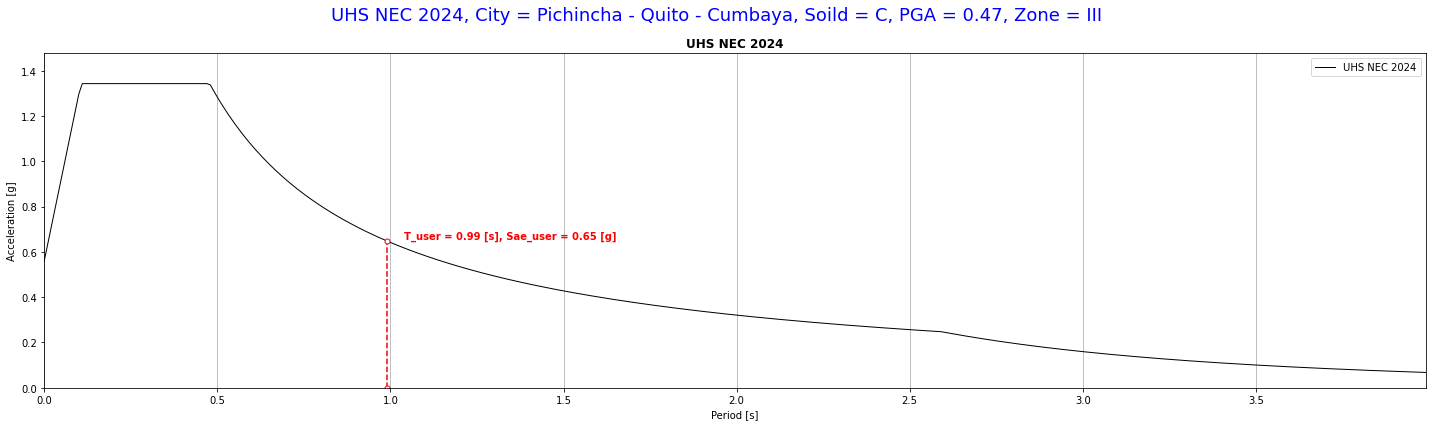

In [8]:
Ta = 0.99
I = 1.25
R = 7
Wr = 65938

fa = 1.19
fd = 1.08
fs = 1.17
ztr475 = 0.47
n = 2.4
Tf = 4
dT = 0.01
r = 1
city = 'Pichincha - Quito - Cumbaya'
soild = 'C'
zone = 'III'

print('='*120)
print(f'Zfa = {ztr475*fa:.2f}')
print('='*120)

SpecMC = SPEC_NEC_2024(z = ztr475,n = n,fa=fa,fd=fd,fs=fs,dT=dT,Tf=Tf,r=r,city=city,soild=soild,pga=ztr475,zone=zone,Tu = Ta)
Sae, Tie, To, Tc, Tl, fa, fd, fs, Saeu = SpecMC.spec()
SpecMC.plotSPECNEC(Tie, Sae, Ta, Saeu)

#### Shear "Basal"

In [9]:
Vtr475 = I * Saeu * Wr / R
Vtr475_por = Vtr475 / Wr * 100

#------ System Type ------
System = 'Dual'
Vwall = Vtr475 * 0.75
Vframe = Vtr475 * 0.25

#-------- print ----------
print("="*120)
print(f'W = {Wr:2f} [T]')
print(f'V = {Vtr475:2f} [T]')
print(f'V = {Vtr475_por:2f} % W')
print(f'Vwall = {Vwall:2f} [T]')
print(f'Vframe = {Vframe:2f} [T]')
print("="*120)

W = 65938.000000 [T]
V = 7628.581304 [T]
V = 11.569325 % W
Vwall = 5721.435978 [T]
Vframe = 1907.145326 [T]


#### (Shear Basal) Distribution

In [10]:
Wfloor_type = 3962
Wfloor_atype = 7090
H = np.ones(14) * 3.6
H[0] = 5
Wfloor = np.ones(14)*Wfloor_type
Wfloor[0] = Wfloor_atype
Wfloor[1] = Wfloor_atype

Ffloor = DisForceLat_NEC_2024(V = Vtr475, H= H,W=Wfloor)

hacum, Fx, Vcomp = Ffloor.FuerzaLateralNEC2024()

# hacum = np.vstack(hacum)
# Fx = np.vstack(Fx)

Fx_wall = Fx * 0.75
Fx_frame = Fx * 0.25

print("="*120)
print(f'V = {Vtr475:.2f} [T]')
print(f'Vc = {Vcomp:.2f} [T]')
print("="*120)

Ffloor_df = pd.DataFrame([hacum, Fx, Fx_wall, Fx_frame])
Ffloor_df

V = 7628.58 [T]
Vc = 7628.58 [T]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,5.000000,8.600000,12.200000,15.800000,19.400000,23.000000,26.600000,30.200000,33.800000,37.400000,41.000000,44.600000,48.200000,51.800000
1,167.157781,287.511383,227.921167,295.176593,362.432020,429.687446,496.942872,564.198299,631.453725,698.709151,765.964577,833.220004,900.475430,967.730856
2,125.368336,215.633538,170.940875,221.382445,271.824015,322.265584,372.707154,423.148724,473.590294,524.031863,574.473433,624.915003,675.356573,725.798142
3,41.789445,71.877846,56.980292,73.794148,90.608005,107.421861,124.235718,141.049575,157.863431,174.677288,191.491144,208.305001,225.118858,241.932714
